In [128]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = 'cpu'
print(f'Using device: {device}')

Using device: cpu


In [129]:
words = open('names.txt', 'r').read().splitlines()
print(words[:8])
print(len(words))

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
32033


In [130]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)
print(stoi)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [131]:
block_size = 3
X, Y = [], []
for w in words:
    context = [0] * block_size
    for c in w + '.':
        ix = stoi[c]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]
X, Y = torch.tensor(X, device=device), torch.tensor(Y, device=device)

In [132]:
print(X.shape, Y.shape, X.dtype, Y.dtype)
print(X[:5], Y[:5])

torch.Size([228146, 3]) torch.Size([228146]) torch.int64 torch.int64
tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1]]) tensor([ 5, 13, 13,  1,  0])


In [133]:
def build_dataset(words):
    block_size = 3
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for c in w + '.':
            ix = stoi[c]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X, Y = torch.tensor(X, device=device), torch.tensor(Y, device=device)
    return X, Y

import random 
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])
print(len(words), n1, n2, f"train: {n1}, dev: {n2-n1}, test: {len(words)-n2}")
print(Xtr.shape, Ytr.shape)
print(Xdev.shape, Ydev.shape)
print(Xte.shape, Yte.shape)


32033 25626 28829 train: 25626, dev: 3203, test: 3204
torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [134]:
emb_dim = 2
C = torch.randn((27, emb_dim), device=device)

In [135]:
emb = C[X]
print(emb.shape)

torch.Size([228146, 3, 2])


In [136]:
W1 = torch.randn((6, 100), device=device)
b1 = torch.randn(100, device=device)


In [137]:
# block_size = 2, emb_dim = 3
# block_size * emb_dim = 6
h = torch.tanh(emb.view(-1, block_size * emb_dim) @ W1 + b1)

In [138]:
h.shape

torch.Size([228146, 100])

In [139]:
W2 = torch.randn((100, 27), device=device)
b2 = torch.randn(27, device=device)
logits = h @ W2 + b2 
counts = torch.exp(logits)
probs = counts / counts.sum(dim=1, keepdim=True)

In [140]:
probs.shape, probs[0].sum(), Y.shape

(torch.Size([228146, 27]), tensor(1.0000), torch.Size([228146]))

In [141]:
X.shape, Y.shape
emb_dim = 10
input_dim = block_size * emb_dim
hidden_dim = 100
g = torch.Generator(device=device).manual_seed(2147483647)
C = torch.randn((27, emb_dim), generator=g, device=device)
W1 = torch.randn((input_dim, hidden_dim), generator=g, device=device)
b1 = torch.randn(hidden_dim, generator=g, device=device)
W2 = torch.randn((hidden_dim, 27), generator=g, device=device)
b2 = torch.randn(27, generator=g, device=device)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True
sum(p.nelement() for p in parameters)

6097

In [142]:
lre = torch.linspace(-3, 3, 1000)
lrs = 10**lre
print(lrs[:10])

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011])


In [143]:
lri = []
lossi = []
stepi = []

In [144]:
total_steps = 400000 
idxs = torch.linspace(0, 1, total_steps)
# use cosine annealing
lrs = 0.1 * torch.cos(idxs * torch.pi / 2)

In [145]:
# plt.plot([i for i in range(total_steps)], lrs.cpu().numpy())

In [146]:
import time
batch_size = 1024 # X.shape[0]
print_interval = 1000
time_start = time.time()
for i in range(total_steps):
    # mini-batch 
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, input_dim) @ W1 + b1)
    logits = h @ W2 + b2
    # counts = torch.exp(logits)
    # probs = counts / counts.sum(dim=1, keepdim=True)
    loss = F.cross_entropy(logits, Ytr[ix])
    lr = lrs[i]
    stepi.append(i)
    # lri.append(lre[i])
    lossi.append(loss.log10().item())
    if i % print_interval == 0:
        elapsed = time.time() - time_start
        time_start = time.time()
        remaining_time = elapsed * (total_steps - i) / print_interval
        print(f'{i}: {loss.item()}, time_elapsed: {elapsed:.2f}s, '
              f'remaining_time: {remaining_time:.2f}s '
              f'{remaining_time/60:.2f}m {remaining_time/3600:.2f}h, '
              f'lr: {lr:.6f}')
    # loss = -probs[torch.arange(32), Y].log().mean()
    # backward pass
    for p in parameters:
        p.grad = None 
    loss.backward()
    # update
    for p in parameters:
        p.data += -p.grad * lr


0: 19.134973526000977, time_elapsed: 0.01s, remaining_time: 2.69s 0.04m 0.00h, lr: 0.100000
1000: 3.011715888977051, time_elapsed: 1.12s, remaining_time: 445.58s 7.43m 0.12h, lr: 0.099999
2000: 2.684870481491089, time_elapsed: 1.11s, remaining_time: 443.76s 7.40m 0.12h, lr: 0.099997
3000: 2.4904096126556396, time_elapsed: 1.10s, remaining_time: 435.26s 7.25m 0.12h, lr: 0.099993
4000: 2.4583187103271484, time_elapsed: 1.11s, remaining_time: 441.12s 7.35m 0.12h, lr: 0.099988
5000: 2.424499034881592, time_elapsed: 1.09s, remaining_time: 430.12s 7.17m 0.12h, lr: 0.099981
6000: 2.3306710720062256, time_elapsed: 1.09s, remaining_time: 430.75s 7.18m 0.12h, lr: 0.099972
7000: 2.3024048805236816, time_elapsed: 1.14s, remaining_time: 447.01s 7.45m 0.12h, lr: 0.099962
8000: 2.2499446868896484, time_elapsed: 1.11s, remaining_time: 436.25s 7.27m 0.12h, lr: 0.099951
9000: 2.3058533668518066, time_elapsed: 1.14s, remaining_time: 447.31s 7.46m 0.12h, lr: 0.099938
10000: 2.339617967605591, time_elapsed

In [147]:
# plt.plot(lri, lossi)

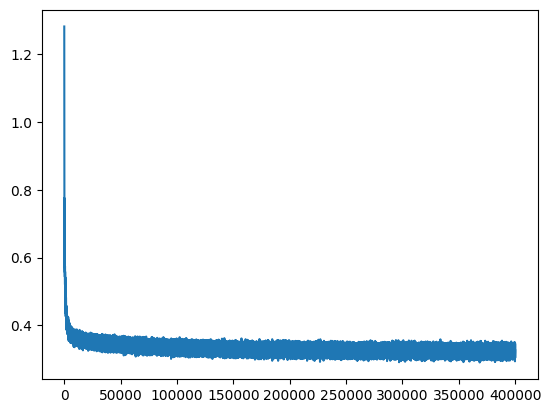

In [148]:
plt.plot(stepi, lossi)

In [149]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, input_dim) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print(f'total loss: {loss.item()}')

total loss: 2.1106112003326416


In [150]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, input_dim) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
print(f'total loss: {loss.item()}') # exp: < 2.17

total loss: 2.144068479537964


In [151]:
g = torch.Generator().manual_seed(2147483647+10)
for i in range(20):
    out = []
    context = [0] * block_size 
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(-1, input_dim) @ W1 + b1)
        logits = h @ W2 + b2 
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        context = context[1:] + [ix]
        if ix == 0:
            break
    print(''.join(out))

pry.
iriana.
bra.
breen.
eyel.
mucclarys.
yurickaol.
dur.
watta.
sardna.
katen.
dru.
macky.
ger.
milah.
brada.
roales.
alyvona.
abbithodde.
niyam.


RuntimeError: Numpy is not available

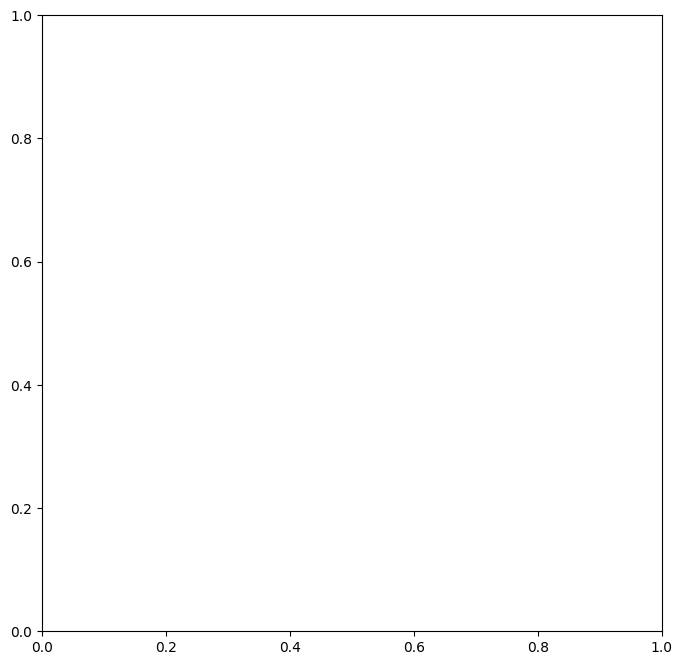

In [152]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
plt.grid(True)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')